In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import altair as alt
#from config_ import nameC_bulk,nameC_cellulose,named13C_bulk, named13C_cellulose, named15N

In [3]:
named13C_cellulose = "δ13C (‰ v.s.V-PDB)"
named13C_bulk = "bulk_δ13C (‰ v.s.V-PDB)"
name18O = "δ18O in ‰ vs DeltaSMOW"
named15N = "δ15N (‰ v.s. V-PDB)"
nameC_bulk ="[C_b]%"
nameC_cellulose = "[C]%"
thick = "mean_thickness_(mm)"
though = "mean_toughness_(kN/m)"
LA = "Leaf area (cm²)"
name = "genus" + "especie"
TreeID_2025 = "TreeID_2025"
old_ID = "treeID_old"

# Guacamayos 2006 
Resultados del 2025 cuando Jurgen me envio las muestras.

In [4]:
## Cellulose results. 

NAPO= pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\specs - AndreaChavez-2025.07.xlsx")
listado = pd.read_excel("Gua_oyc_listado.xlsx")

NAPO_2006 = NAPO[NAPO["Meas batch"].str.contains("NAPO2006", na=False)]

#NAPO_add = NAPO[NAPO["Sample ID"].isin(["p07-183"])] #HELP Check p09-0122, p09-0140
patrones = ["p06","p6","p7","p07","p08","p8","p27","p55"]#guacamayos 2006 enviados por Jurgen

filtrado_GUA = NAPO_2006[NAPO_2006["Sample ID"].str.contains("|".join(patrones), na=False)]
NAPO_add = NAPO[NAPO["Sample ID"].isin(["p07-183"])] #HELP Check p09-0122, p09-0140. COntroles

filtrado_GUA = pd.concat([filtrado_GUA, NAPO_add])
filtrado_GUA[["Plot","old treeID"]] =filtrado_GUA["Sample ID"].str.split("-",expand=True) 
filtrado_GUA["Type"] = "leaf pulverized"
filtrado_GUA = filtrado_GUA.drop(columns=["Meas batch","Comment"])
filtrado_GUA = filtrado_GUA.rename(columns={"δ13C":named13C_cellulose,"[C] in %":nameC_cellulose})


## Nutrientes Guacamayos 2006

In [5]:
#bulk HELP: añadir los años 
SEQ1= pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea_bulk CN_2025.xlsx",sheet_name="SEQ1")
SEQ1 = SEQ1.iloc[7:] #deletes first 7 rows #SEQ1. Aca hay de Guacamayos
SEQ2 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea_bulk CN_2025.xlsx",sheet_name="SEQ2")
SEQ2 = SEQ2.iloc[56:73+1] # aca hay p6,p7,p8 al final
#SEQ4 = pd.read_excel("Andrea_bulk CN_2025.xlsx",sheet_name="SEQ4")
#SEQ4 = SEQ4.iloc[7:]
#SEQ4["year"] = 2025
#SEQ5 = pd.read_excel("Andrea_bulk CN_2025.xlsx",sheet_name="SEQ5")
#SEQ5 = SEQ5.iloc[7:]
SEQ7 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea_bulk CN_2025.xlsx",sheet_name="SEQ7")
SEQ7 = SEQ7.iloc[51:] # aca hay 23 y 29

bulk = pd.concat([SEQ1,SEQ2,SEQ7])
bulk = bulk.rename(columns={"certified values":"sample-ID", "Unnamed: 2":"[N]",
                            "Unnamed: 4":nameC_bulk,"Unnamed: 6":named15N,
                            "Unnamed: 8":named13C_bulk})
bulk = bulk.iloc[1:]#delete first row

bulk[["Plot","old treeID","a"]] =bulk["sample-ID"].str.split("-",expand=True)
columns_drop = ["Unnamed: 0", "Unnamed: 3","Unnamed: 5","Unnamed: 7", "Unnamed: 9","Unnamed: 10","Unnamed: 11","Unnamed: 12","a"]

patrones = ["p06","p6","p7","p07","p08","p8","p27","p55"]#guacamayos 2006 enviados por Jurgen

bulk = bulk[bulk["Plot"].str.contains("|".join(patrones), na=False)]

bulk = bulk.drop(columns=columns_drop)


In [6]:
### cellulose and bulk 2006

merged = pd.merge(filtrado_GUA,bulk, left_on="old treeID", right_on="old treeID", how="outer")
merged["Plot"] = merged["Plot_x"].combine_first(merged["Plot_y"])
drop = ["Sample ID","Plot_y","Plot_x"]
merged = merged.drop(columns = drop)
#merged["Site"] = "Guacamayos" #todos son Guacamayos 2006

cellulose_bulk_2006 = merged
cellulose_bulk_2006 = cellulose_bulk_2006.rename(columns={"[C] in %":nameC_cellulose,"δ13C":named13C_cellulose,"old treeID":"treeID_old"})

In [7]:
### Rasgos funcionales 2006

info = pd.read_excel("samples2006_Guacamayos&Galeras.xlsx") #rasgos 2006
info_gua = info[info["site"]=="Guacamayos"]
info_gua = info_gua[["site","plot","#","family","species (det 2008!)"]] #Cuando necesite añado los otros. Por ahora no

cellulose_bulk_2006["treeID_old"] = cellulose_bulk_2006["treeID_old"].astype("Float64")
GUA_2006 = pd.merge(cellulose_bulk_2006,info_gua, left_on = "treeID_old",right_on="#", how="outer") # El plot 27 Nan
GUA_2006["treeID_old"] = GUA_2006["treeID_old"].combine_first(GUA_2006["#"]) #limpiamos para unificar
GUA_2006 = GUA_2006.drop(columns=["site","Plot","#"])
GUA_2006["Year"] = 2006
GUA_2006["Site"] = "Guacamayos"

### quiero añadir informacion de las nuevas TreeID para relacionar con los arboles 
TreesID = pd.read_excel("02. Rasgos Guacamayos.xlsx")
TreesID = TreesID[["Plot","altitud","TreeID_2025","oldTreeID"]] #mantenemos el original porque le necesito abajo.
#TreesID = TreesID[["Plot","altitud","Date ","TreeID_2025","oldTreeID","SLA (cm2/g)","mean_thickness_(mm)"]]

GUA_2006_info = pd.merge(TreesID,GUA_2006, right_on= "treeID_old", left_on= "oldTreeID", how="right" )
GUA_2006_info["treeID_old"] = GUA_2006_info["treeID_old"].combine_first(GUA_2006_info["oldTreeID"]) #limpiamos para unificar
GUA_2006_info = GUA_2006_info.drop(columns=["oldTreeID","Plot"])# innecesaria #quedan varios espacios vacios especialmente por los rasgos de 2025.
GUA_2006_info = GUA_2006_info.rename(columns={"treeID_old":"treeID_old","TreeID_2025":"treeID_new","δ13C (‰ v.s.V-PDB)":named13C_cellulose,"plot":"Plot"})
GUA_2006_info.head(3)

,altitud,treeID_new,[C]%,δ13C (‰ v.s.V-PDB),treeID_old,Type,sample-ID,[N],[C_b]%,δ15N (‰ v.s. V-PDB),bulk_δ13C (‰ v.s.V-PDB),Plot,family,species (det 2008!),Year,Site
0,1940.0,8147.0,42.315329,-28.146376,178.0,leaf pulverized,p7-178,0.031029,0.538528,0.69,-30.14,7.0,Rubiaceae,Chomelia tenuiflora,2006,Guacamayos
1,2000.0,8200.0,44.184757,-28.291668,169.0,leaf pulverized,p6-169,0.03072,0.45444,0.35,-29.69,6.0,Asteraceae,Critoniopsis cf occidentalis,2006,Guacamayos
2,1995.0,8141.0,44.049363,-26.008882,210.0,leaf pulverized,p8-210,0.027914,0.405596,2.62,-26.75,8.0,Fabaceae,Erythrina edulis,2006,Guacamayos


## First year: Oyacachi + few herbarium from Guacamayos

In [8]:
#cellulose
results_ISMR = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Resultis_ISMR_10072024.xlsx", sheet_name = "seq 1") #only seq1 has Napo results
subset = results_ISMR[["sample-ID","[C] m/m (%)","δ13C (‰ v.s. V-PDB)"]]
subset = subset.rename(columns = {"[C] m/m (%)":nameC_cellulose,"δ13C (‰ v.s. V-PDB)":named13C_cellulose})

## bulk
bulk = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\data overview.xlsx")
add = bulk[bulk["Sample"].isin([8023,56079,8194,8200])]
napo_bulk = bulk[bulk["Meas batch"] == "CN_S1"]
drop_columns = ["Unnamed: 2","Unnamed: 4","Unnamed: 6","Unnamed: 8","Meas batch"] #Aca hay unas desviaciones estandar. 0.118854 por ejemplo
napo_bulk = napo_bulk.drop(columns= drop_columns)

### bulk complete
mix_oyc_gua = pd.concat([napo_bulk,add])
mix_oyc_gua = mix_oyc_gua.rename(columns = {"[C] m/m":nameC_bulk,"δ13C (‰ v.s. V-PDB)":named13C_bulk,"[N] m/m":"[N]","δ15N (‰ v.s. V-PDB)":named15N})
mix_oyc_gua = mix_oyc_gua.drop(columns = drop_columns)
mix_oyc_gua

,Sample,[N],δ15N (‰ v.s. V-PDB),[C_b]%,bulk_δ13C (‰ v.s.V-PDB)
0,1689,3.357924,1.907002,41.921147,-27.333327
1,1711,1.996007,0.756532,42.594045,-31.069542
2,1715,2.765898,2.185417,44.371695,-31.492877
3,1738,2.053133,2.249046,46.564344,-31.687973
4,3150,3.044708,3.191434,38.714349,-30.713244
...,...,...,...,...,...
91,56128,2.557618,-1.288416,45.3998,-27.648438
64,8194,2.014609,0.49784,44.657171,-30.453959
65,8200,3.279822,1.691458,44.152205,-29.231435
339,8023,2.301508,43.157492,-1.422247,-30.800863


In [9]:
### muestras 2011 pulverizadas que son solo de OYC. 
# OK 

listado_2011 = listado[listado["leaf_sample_ID_2011"].notna()]
listado_2011[["leaf_sample_ID_2011","treeID_old","treeID_new","Site","family","species","herbarium specimen"]]

cell_2011 = pd.merge(listado_2011,subset,left_on="leaf_sample_ID_2011",right_on="sample-ID",how="left")
cell_2011 = cell_2011.drop(columns=["collection year","ID_Andrea"]) #ese TreeID es sampleID

cel_bulk_2011 = pd.merge(cell_2011,mix_oyc_gua,left_on="leaf_sample_ID_2011",right_on="Sample",how="left")
cel_bulk_2011 = cel_bulk_2011.drop(columns=["herbaria","sample-ID","Sample","pulverized"])
#cel_bulk_2011 = cel_bulk_2011.rename(columns=["herbaria","sample-ID","Sample","pulverized"])

cel_bulk_2011["Year"] = 2011
cel_bulk_2011["Type"] = "leaf pulverized"

In [10]:
### muestras del herbario
## OK
listado_hb = listado[listado["herbarium specimen"].notna()]
listado_hb[["herbarium specimen","treeID_old","treeID_new","Site","family","species"]]

cell_hb = pd.merge(listado_hb,subset,left_on="herbarium specimen",right_on="sample-ID",how="left")
cell_hb = cell_hb.drop(columns=["ID_Andrea","leaf_sample_ID_2011","pulverized","herbaria"]) #ese TreeID es sampleID
cell_hb = cell_hb.dropna() #son solo 7
cell_hb = cell_hb.rename(columns={"collection year":"Year","[N] m/m}":"[N]"}) #homogeneize columns
cell_hb["Type"] = "herbarium"

cel_bulk_hb = pd.merge(cell_hb,mix_oyc_gua,left_on="herbarium specimen",right_on="Sample",how="left")
cel_bulk_hb = cel_bulk_hb.drop(columns=["sample-ID","Sample"])

## Muestras pulverizadas 2023
Esos codigos deben ser asignados TreeIDs

In [11]:
#homogeneizar los nombres
def homogeneizar(df,columna_nombre):
 df[columna_nombre] = df[columna_nombre].replace({4101:8076,
                             4101:8067,
                             4105:8071,
                             4244:8068,
                             4027:8052,
                             4020:8016,
                             4100:8066,
                             "4838.1":4838,#eliminar
                            "4838.2":4838,
                             161:8194,
                             169:8200,
                             4021:8013,
                             4100:8066,
                             186:8151,
                             151:8182,
                             4022:8039,
                             4043:8080,
                             4106:8076
                    })
 return df

In [12]:
#remove from samples 
lista = cel_bulk_hb["herbarium specimen"].tolist() + \
        cel_bulk_2011["leaf_sample_ID_2011"].tolist()

cel_2025 = subset[~subset["sample-ID"].isin(lista)]
cel_2025 = homogeneizar(cel_2025,"sample-ID")

### datos de los tests
nuevos = pd.DataFrame({
    "sample-ID": [8154, 8182, 8151],
    nameC_cellulose: [46.84, 45.65, 46.30],
    named13C_cellulose: [-30.02, -30.25, -26.81]
})

cel_2025 = pd.concat([cel_2025, nuevos], ignore_index=True)

bulk_2025 = mix_oyc_gua[~mix_oyc_gua["Sample"].isin(lista)]
bulk_2025 = homogeneizar(bulk_2025,"Sample")

samples_2025 = pd.merge(cel_2025,bulk_2025,left_on="sample-ID",right_on="Sample",how="outer")
listado = listado[["Plot","treeID_new","treeID_old","family","species","Site"]]
cel_bulk_2025 = pd.merge(listado,samples_2025, left_on="treeID_new",right_on="Sample",how="outer") #Sample esta completo
cel_bulk_2025 = cel_bulk_2025.drop(columns={"Sample"})
cel_bulk_2025["Year"]=2023
cel_bulk_2025["Type"]="pulverized"


C:\Users\selene.baez\AppData\Local\Temp\ipykernel_18652\2577713693.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[columna_nombre] = df[columna_nombre].replace({4101:8076,
C:\Users\selene.baez\AppData\Local\Temp\ipykernel_18652\2577713693.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[columna_nombre] = df[columna_nombre].replace({4101:8076,
C:\Users\selene.baez\AppData\Local\Temp\ipykernel_18652\3872073201.py:20: UserWarning: You are merging on int and float columns where the float values are

In [13]:
df1 = pd.concat([cel_bulk_2011,cel_bulk_2025,cel_bulk_hb]) #primero unificar este
all= pd.concat([df1,GUA_2006_info])
all.to_excel("test.xlsx")

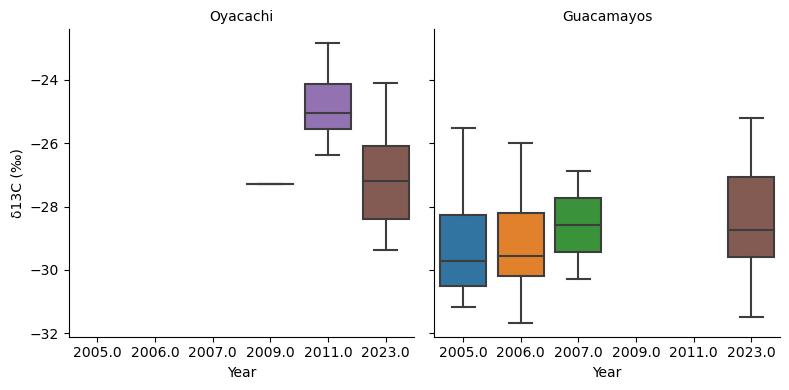

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=all,
    x="Year",
    y= "δ13C (‰ v.s.V-PDB)",   # o el nombre exacto de tu columna
    col="Site",     # facet por sitio
    kind="box",
    height=4,
    aspect=1
)

g.set_axis_labels("Year", "δ13C (‰)")
g.set_titles("{col_name}")  # título = nombre del sitio

plt.show()

In [15]:
import calculate_iWUE_oyc
%run calculate_iWUE_oyc

df = all.apply(lambda row: calculate_iWUE(row, co2_dict), axis=1)

In [16]:
import elevation_dict
%run elevation_dict
df["Elevation"] = df.set_index(["Site", "Plot"]).index.map(elevation_dict)


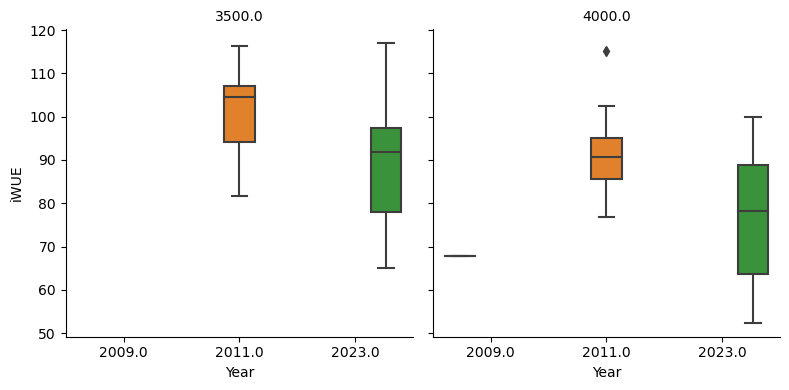

In [17]:
OYC  = df[df["Site"]=="Oyacachi"]

palette = {
    2009: "grey",
    2011: "blue",
    2023: "orange"
}

g = sns.catplot(
    data=OYC,
    x="Year",
    y= "iWUE (μmol/mol)",   # o el nombre exacto de tu columna
    col="Elevation",     # facet por sitio
    kind="box",
    hue="Year",
    height=4,
    aspect=1
    
)


g.set_axis_labels("Year", "iWUE")
g.set_titles("{col_name}")  # título = nombre del sitio

plt.show()

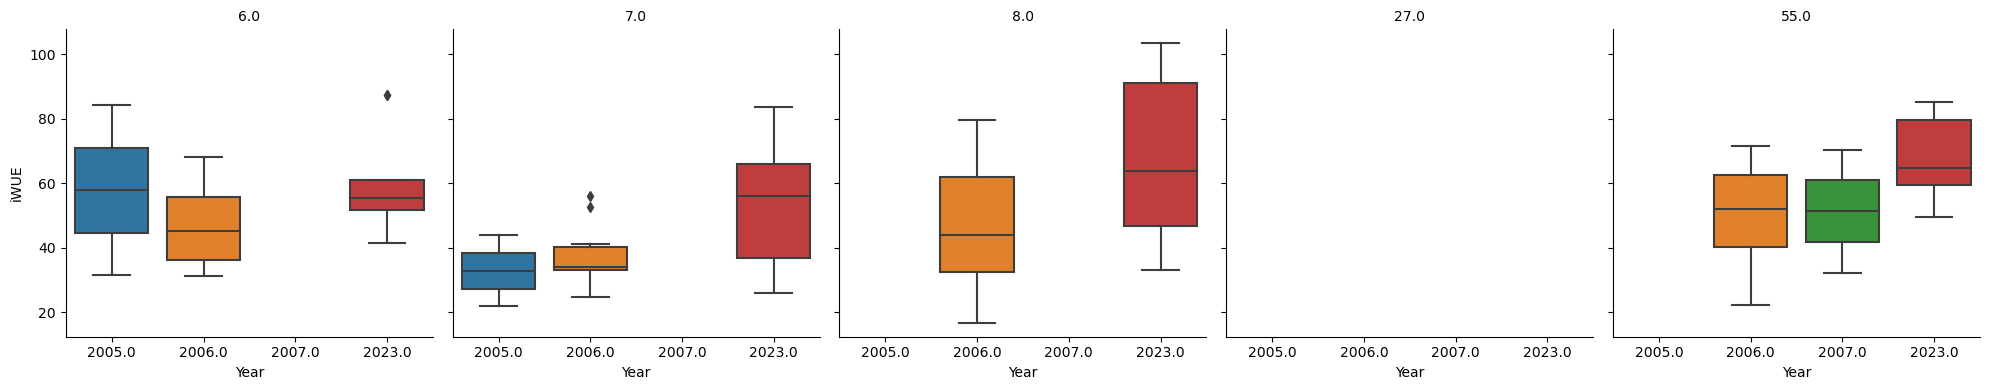

In [18]:
GUA  = df[df["Site"]=="Guacamayos"]

g = sns.catplot(
    data=GUA,
    x="Year",
    y= "iWUE (μmol/mol)",   # o el nombre exacto de tu columna
    col="Plot",     # facet por sitio
    kind="box",
    height=4,
    aspect=1
)

g.set_axis_labels("Year", "iWUE")
g.set_titles("{col_name}")  # título = nombre del sitio

plt.show()

In [19]:
df = df.rename(columns={"treeID_new":"new_TreeID","treeID_old":"old_treeID","sample-ID":"Sample-ID"})
df.to_excel("iWUE_OYC_GUA.xlsx")